In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("../data/processed")
euro = pd.read_parquet(PROCESSED / "euro_matches_clean.parquet")
spi = pd.read_parquet(PROCESSED / "spi_clean.parquet")
print(euro.shape, spi.shape)

(25979, 16) (10710, 20)


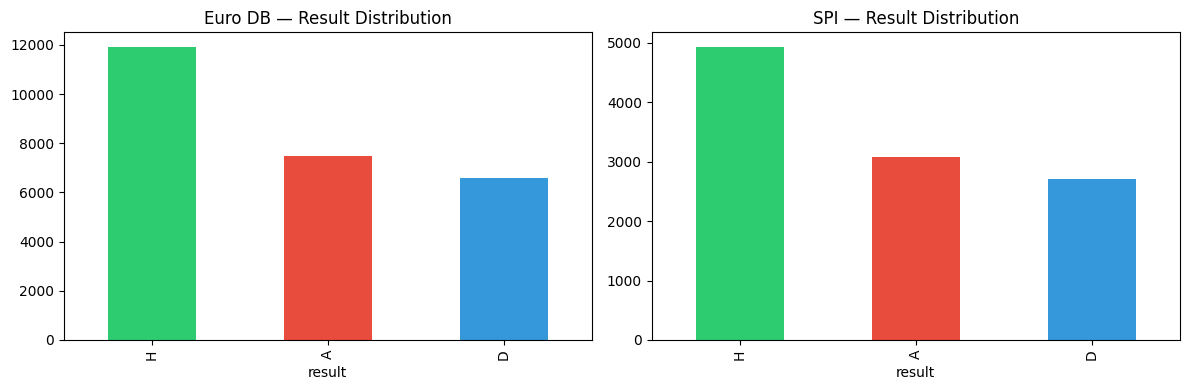

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
euro["result"].value_counts().plot(kind="bar", ax=axes[0], color=["#2ecc71","#e74c3c","#3498db"])
axes[0].set_title("Euro DB — Result Distribution")
spi["result"].value_counts().plot(kind="bar", ax=axes[1], color=["#2ecc71","#e74c3c","#3498db"])
axes[1].set_title("SPI — Result Distribution")
plt.tight_layout()
plt.show()

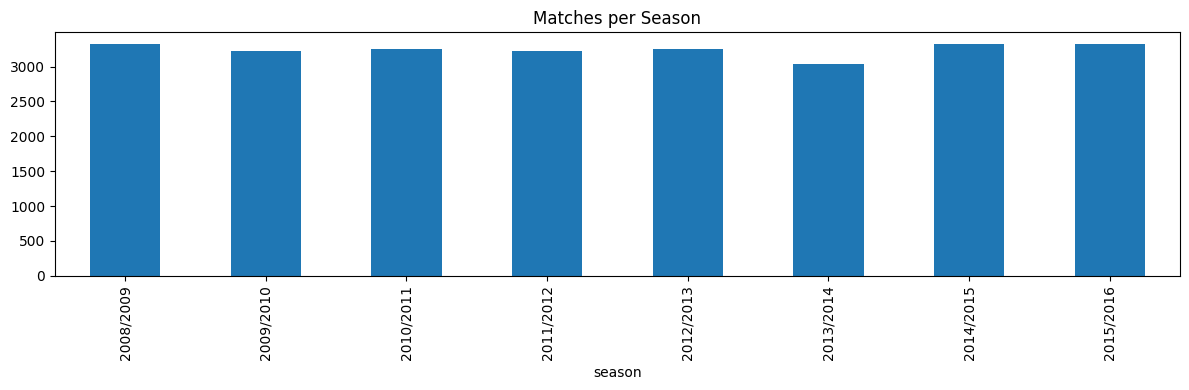

In [4]:
euro["season"].value_counts().sort_index().plot(kind="bar", figsize=(12, 4))
plt.title("Matches per Season")
plt.tight_layout()
plt.show()

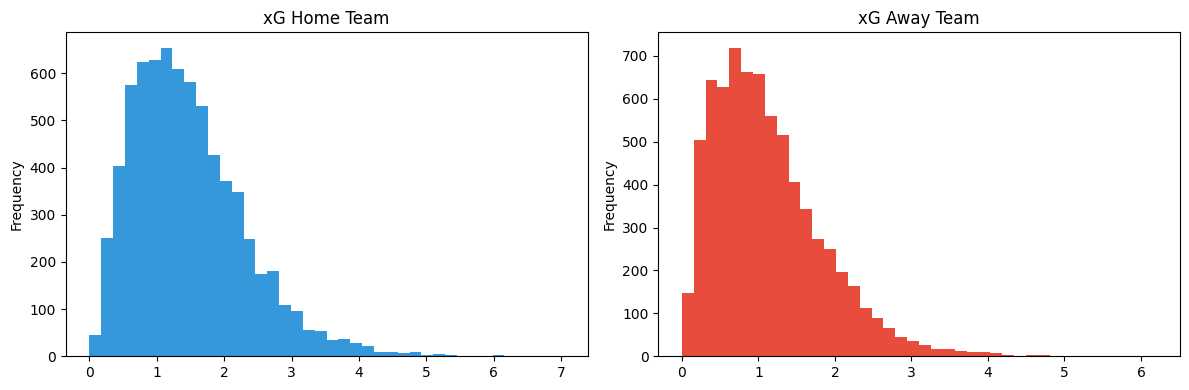

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
spi["xg1"].plot(kind="hist", bins=40, ax=axes[0], color="#3498db")
axes[0].set_title("xG Home Team")
spi["xg2"].plot(kind="hist", bins=40, ax=axes[1], color="#e74c3c")
axes[1].set_title("xG Away Team")
plt.tight_layout()
plt.show()

In [6]:
euro["home_team_goal"].mean(), euro["away_team_goal"].mean()

(np.float64(1.5445937103044767), np.float64(1.1609376804341969))

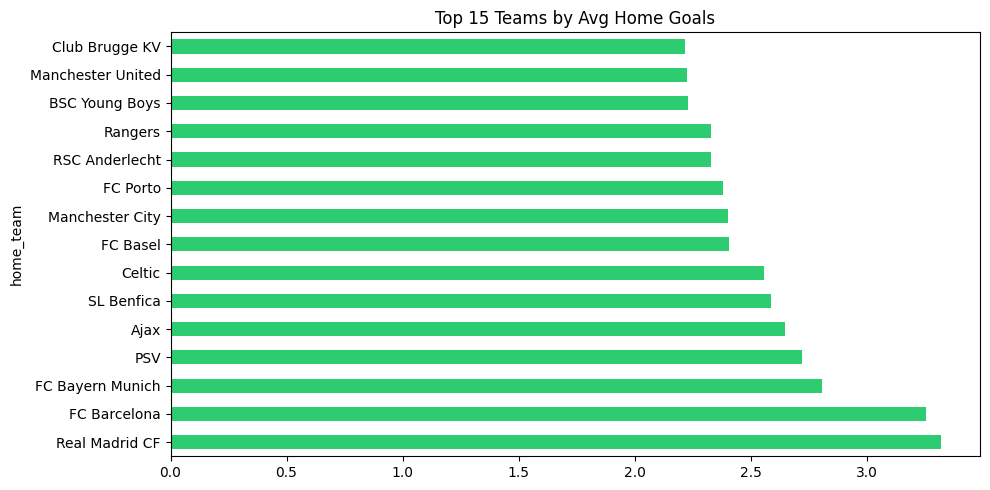

In [7]:
top = euro.groupby("home_team")["home_team_goal"].mean().sort_values(ascending=False).head(15)
top.plot(kind="barh", figsize=(10, 5), color="#2ecc71")
plt.title("Top 15 Teams by Avg Home Goals")
plt.tight_layout()
plt.show()